<a href="https://colab.research.google.com/github/swathi942/App-User-Behavior-Segmentation-Dashboard/blob/main/app_user_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("app_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [ ]:
print(df.describe())

             user_id           age   app_version  sessions_per_week  \
count   50000.000000  50000.000000  50000.000000       50000.000000   
mean   124999.500000     38.513040      1.476126           7.999680   
std     14433.901067     12.094948      0.470158           2.829438   
min    100000.000000     18.000000      1.000000           0.000000   
25%    112499.750000     28.000000      1.100000           6.000000   
50%    124999.500000     39.000000      1.200000           8.000000   
75%    137499.250000     49.000000      2.000000          10.000000   
max    149999.000000     59.000000      2.100000          26.000000   

       avg_session_duration_min  daily_active_minutes  \
count              50000.000000          50000.000000   
mean                  13.149842             45.164537   
std                    8.946944             19.505118   
min                    0.060000              5.000000   
25%                    6.570000             31.650000   
50%               

In [ ]:
print(df.isnull().sum())

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

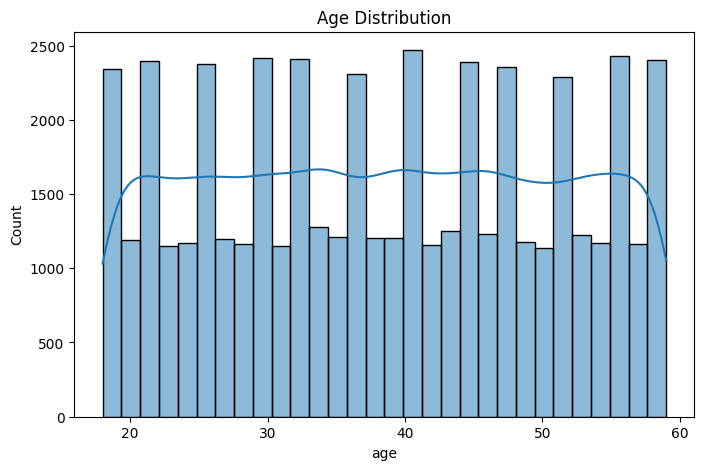

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

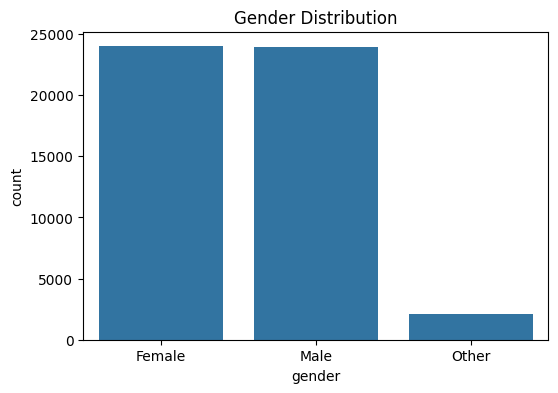

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()

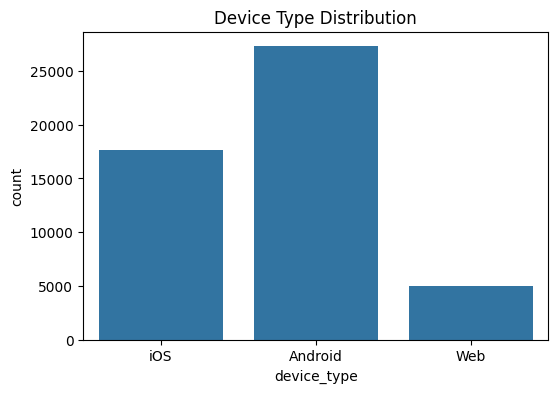

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='device_type', data=df)

plt.title("Device Type Distribution")
plt.show()

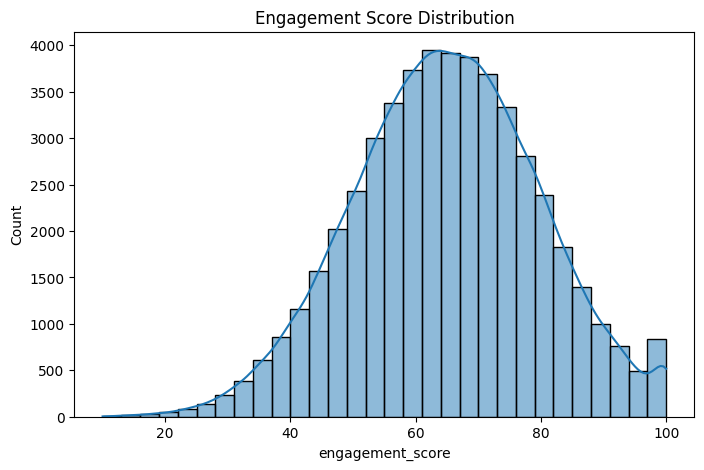

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['engagement_score'], bins=30, kde=True)

plt.title("Engagement Score Distribution")
plt.show()

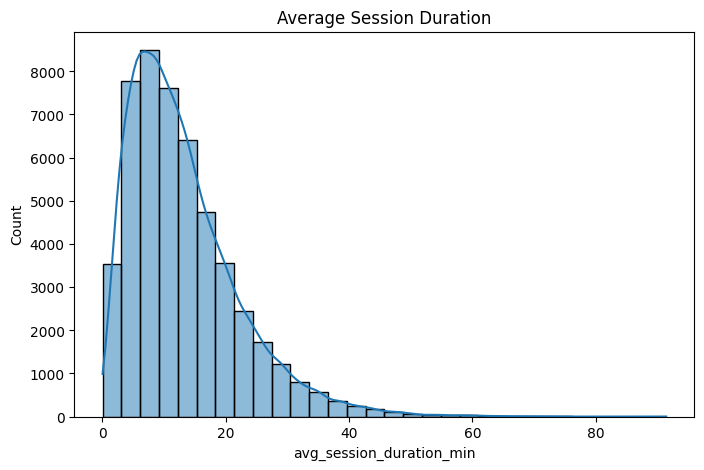

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['avg_session_duration_min'], bins=30, kde=True)

plt.title("Average Session Duration")
plt.show()

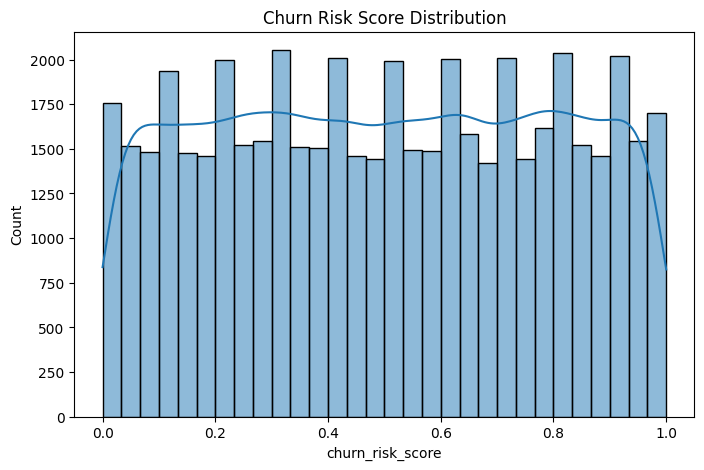

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['churn_risk_score'], bins=30, kde=True)

plt.title("Churn Risk Score Distribution")
plt.show()

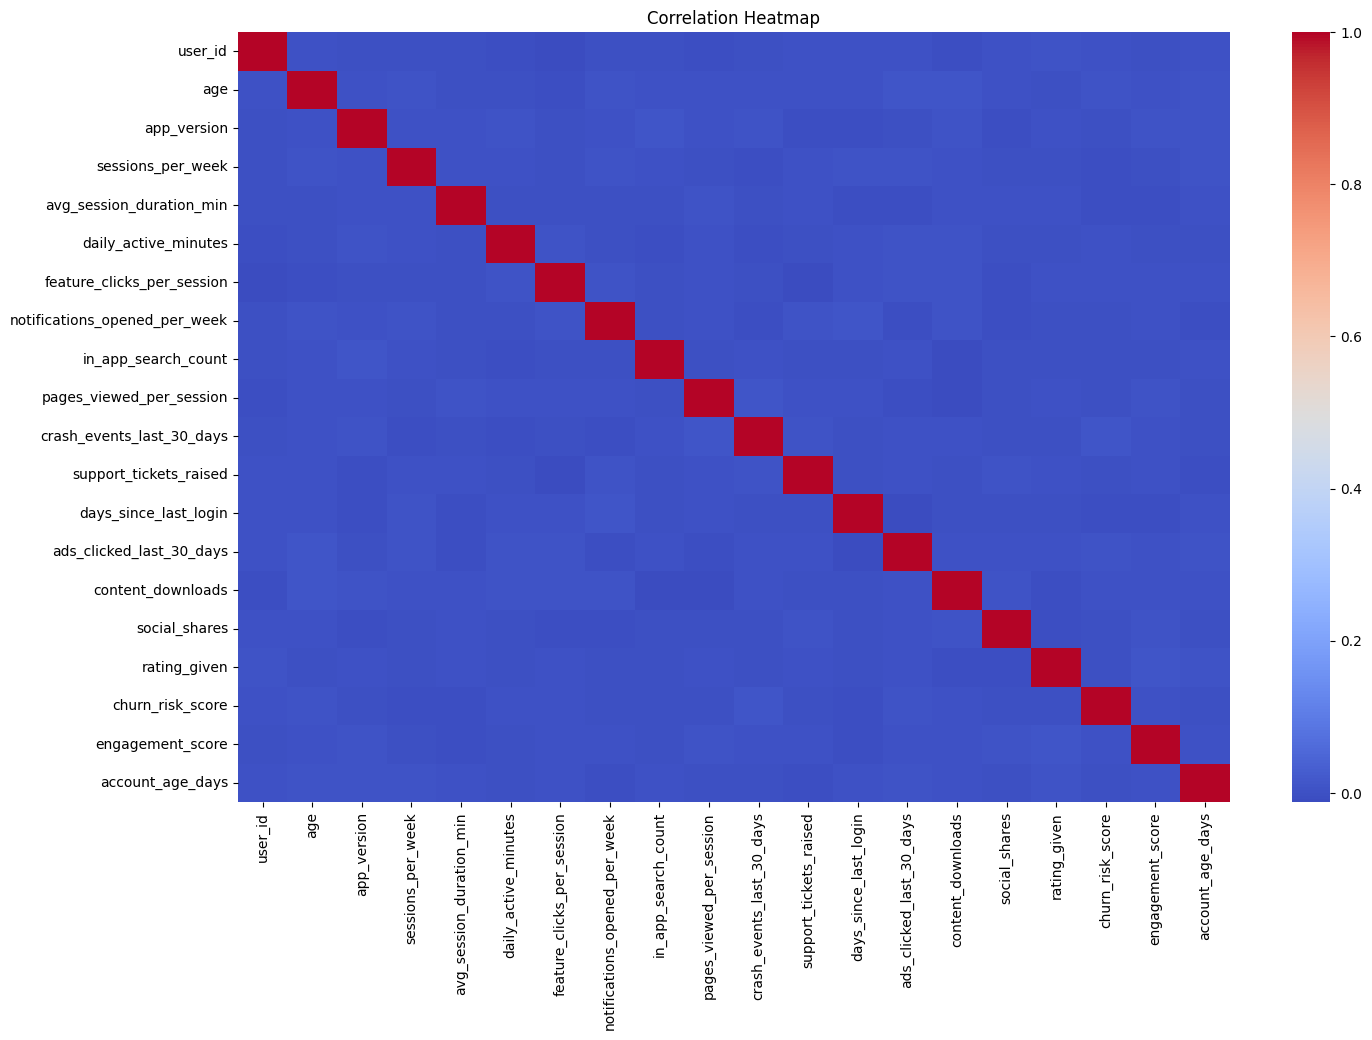

In [ ]:
plt.figure(figsize=(16,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

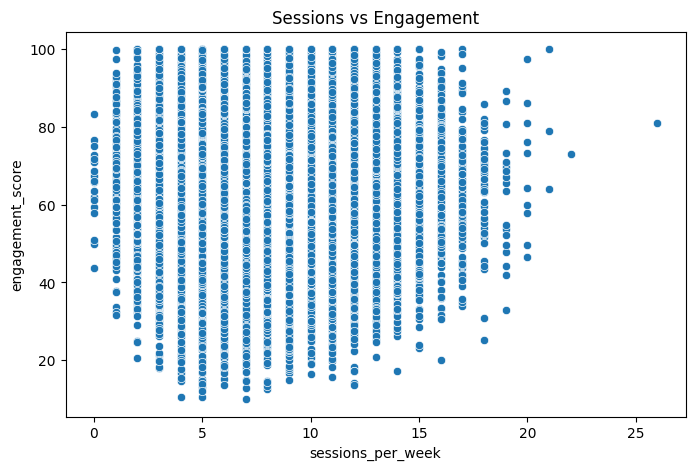

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sessions_per_week',
    y='engagement_score',
    data=df
)

plt.title("Sessions vs Engagement")

plt.show()

In [ ]:
features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'ads_clicked_last_30_days',
    'content_downloads',
    'social_shares',
    'engagement_score',
    'churn_risk_score'
]

X = df[features]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

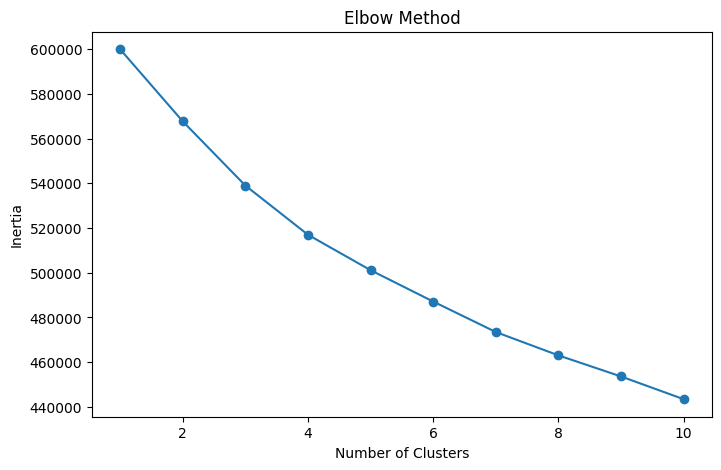

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

In [ ]:
df['Cluster'] = kmeans.labels_

In [ ]:
score = silhouette_score(X_scaled, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.059899833488566485


In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [ ]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = df['Cluster']

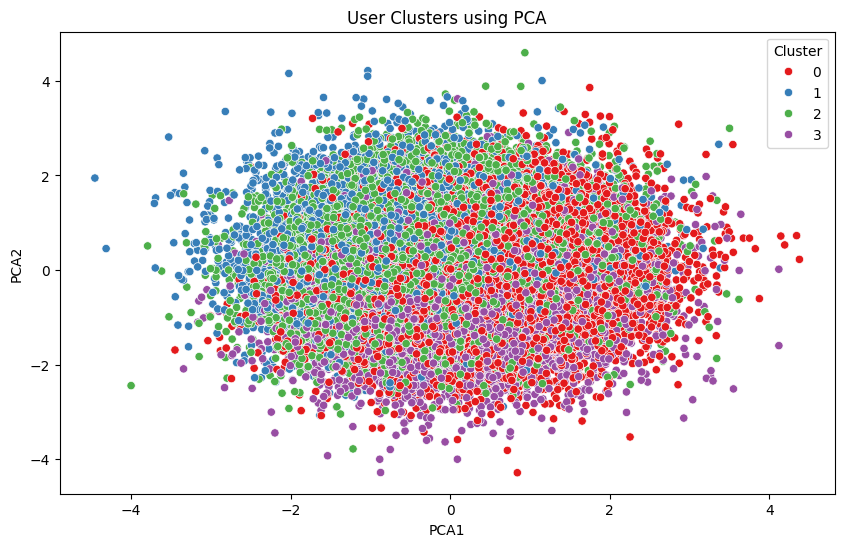

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("User Clusters using PCA")

plt.show()

In [ ]:
cluster_profile = df.groupby('Cluster')[features].mean()

print(cluster_profile)

         sessions_per_week  avg_session_duration_min  daily_active_minutes  \
Cluster                                                                      
0                 7.978211                 10.193248             45.198226   
1                 8.051998                 29.295561             45.183389   
2                 7.983181                 10.116267             45.258833   
3                 8.021557                 11.096126             44.955098   

         feature_clicks_per_session  notifications_opened_per_week  \
Cluster                                                              
0                         12.067348                       4.988115   
1                         11.930761                       4.922687   
2                         12.063664                       5.030462   
3                         11.913392                       5.009443   

         in_app_search_count  pages_viewed_per_session  \
Cluster                                             

In [ ]:
print(df['Cluster'].value_counts())

Cluster
0    16155
2    16053
3    10484
1     7308
Name: count, dtype: int64


In [ ]:
cluster_names = {
    0: 'High Engagement Users',
    1: 'Moderate Engagement Users',
    2: 'Low Engagement Users',
    3: 'Occasional Users'
}


df['User_Group'] = df['Cluster'].map(cluster_names)

In [ ]:
df.to_csv("App_user_behaviour_cleaned.csv", index=False)
print("CSV saved successfully!")


CSV saved successfully!


In [ ]:
from google.colab import files
files.download("App_user_behaviour_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>